In [1]:
import pandas as pd
import numpy as np
import json
from datetime import datetime, timedelta

# Configurações da simulação
num_jogadas = 100
mesa_comprimento = 274  # cm
mesa_largura = 152.5    # cm

data_list = []

for i in range(num_jogadas):
    timestamp = datetime.now() + timedelta(milliseconds=i*100)

    # Gerando coordenadas e velocidade aleatórias (simulando sensores)
    record = {
        "sensor_id": "cam_01",
        "timestamp": timestamp.isoformat(),
        "ball_pos_x": round(np.random.uniform(0, mesa_comprimento), 2),
        "ball_pos_y": round(np.random.uniform(0, mesa_largura), 2),
        "ball_speed_kmh": round(np.random.normal(30, 10), 2), # Média 30km/h
        "hit_type": np.random.choice(["forehand", "backhand", "serve"], p=[0.4, 0.4, 0.2])
    }
    data_list.append(record)

# Salvando como nosso "Data Lake" inicial (JSON)
with open('raw_pingpong_data.json', 'w') as f:
    json.dump(data_list, f)

print(f"✅ {num_jogadas} registros gerados com sucesso em 'raw_pingpong_data.json'!")

✅ 100 registros gerados com sucesso em 'raw_pingpong_data.json'!


In [2]:
# Lendo os dados do nosso "Data Lake" (JSON)
df = pd.read_json('raw_pingpong_data.json')

# 1. Transformação: Converter timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Enriquecimento: Criar métrica em m/s (dividir km/h por 3.6)
df['ball_speed_ms'] = round(df['ball_speed_kmh'] / 3.6, 2)

# 3. Análise: Agrupar por tipo de golpe e calcular médias
analise_performance = df.groupby('hit_type').agg({
    'ball_speed_kmh': 'mean',
    'ball_speed_ms': 'mean',
    'sensor_id': 'count'
}).rename(columns={'sensor_id': 'total_jogadas'}).reset_index()

# Exibindo o resultado final (Nosso "Data Warehouse")
print("--- Tabela de Performance de Ping-Pong ---")
print(analise_performance)

# Salvando o dado processado para o time de Data Science/Analytics
analise_performance.to_csv('refined_pingpong_stats.csv', index=False)

--- Tabela de Performance de Ping-Pong ---
   hit_type  ball_speed_kmh  ball_speed_ms  total_jogadas
0  backhand       29.620943       8.227170             53
1  forehand       28.878788       8.022121             33
2     serve       30.757143       8.542857             14


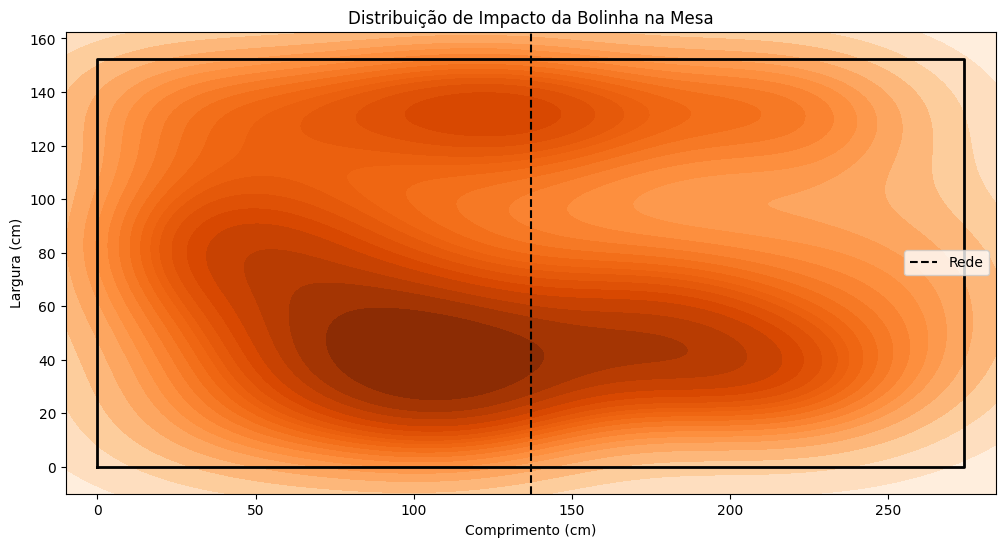

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o tamanho da mesa (274cm x 152.5cm)
mesa_comprimento = 274
mesa_largura = 152.5

# Criando a visualização
plt.figure(figsize=(12, 6))

# Gerando o heatmap baseado nas coordenadas (x, y)
sns.kdeplot(x=df.ball_pos_x, y=df.ball_pos_y,
            fill=True, cmap="Oranges", thresh=0, levels=20)

# Desenhando o contorno da mesa e a rede
plt.plot([0, mesa_comprimento, mesa_comprimento, 0, 0],
         [0, 0, mesa_largura, mesa_largura, 0], color='black', lw=2)
plt.axvline(x=mesa_comprimento/2, color='black', linestyle='--', label='Rede')

plt.title('Distribuição de Impacto da Bolinha na Mesa')
plt.xlabel('Comprimento (cm)')
plt.ylabel('Largura (cm)')
plt.xlim(-10, mesa_comprimento + 10)
plt.ylim(-10, mesa_largura + 10)
plt.legend()
plt.show()

In [4]:
# Simulando um erro de leitura (sensor maluco)
df.loc[0, 'ball_speed_kmh'] = 999.0  # Velocidade supersônica impossível

# Regra de Negócio: Velocidade deve estar entre 0 e 120 km/h
# E as coordenadas devem estar dentro dos limites da mesa
mask_valid = (df['ball_speed_kmh'] >= 0) & (df['ball_speed_kmh'] <= 120) & \
             (df['ball_pos_x'].between(0, mesa_comprimento)) & \
             (df['ball_pos_y'].between(0, mesa_largura))

df_clean = df[mask_valid].copy()

print(f"Registros Totais: {len(df)}")
print(f"Registros Válidos: {len(df_clean)}")
print(f"Dados descartados (Lixo): {len(df) - len(df_clean)}")

Registros Totais: 100
Registros Válidos: 99
Dados descartados (Lixo): 1


In [5]:
import time
from IPython.display import clear_output

# Simulando o Stream de Dados (Hot Path)
print("🚀 Iniciando captura de dados da mesa em tempo real...")
time.sleep(2)

buffer_streaming = []

try:
    for i in range(1, 21): # Simulando 20 jogadas seguidas
        # 1. Ingestão (Gerando o dado do sensor)
        novo_evento = {
            "jogada_id": i,
            "timestamp": datetime.now().strftime("%H:%M:%S"),
            "velocidade": round(np.random.normal(35, 12), 2),
            "tipo": np.random.choice(["Topspin", "Slice", "Saque"])
        }

        # 2. Processamento (Transformação em voo)
        novo_evento['status'] = "⚡ ALTA VELOCIDADE" if novo_evento['velocidade'] > 45 else "🐢 Normal"
        buffer_streaming.append(novo_evento)

        # 3. Visualização do Dashboard (Live Update)
        clear_output(wait=True)
        print(f"=== 🏓 SMART PONG LIVE DASHBOARD ===")
        print(f"Última Jogada: {novo_evento['timestamp']} | Tipo: {novo_evento['tipo']}")
        print(f"Velocidade: {novo_evento['velocidade']} km/h ({novo_evento['status']})")
        print("-" * 40)

        # Exibindo o histórico recente
        df_stream = pd.DataFrame(buffer_streaming)
        print(df_stream.tail(5)[['jogada_id', 'tipo', 'velocidade', 'status']].to_string(index=False))

        time.sleep(1.5) # Pausa para simular o tempo entre batidas

except KeyboardInterrupt:
    print("\n🛑 Stream interrompido pelo usuário.")

print("\n✅ Partida finalizada! Dados salvos no Buffer.")

=== 🏓 SMART PONG LIVE DASHBOARD ===
Última Jogada: 15:31:58 | Tipo: Saque
Velocidade: 42.78 km/h (🐢 Normal)
----------------------------------------
 jogada_id    tipo  velocidade            status
        16   Saque       32.43          🐢 Normal
        17 Topspin       51.71 ⚡ ALTA VELOCIDADE
        18 Topspin       34.20          🐢 Normal
        19 Topspin       19.18          🐢 Normal
        20   Saque       42.78          🐢 Normal

✅ Partida finalizada! Dados salvos no Buffer.
